In [4]:
!pip install ultralytics

  Using cached ultralytics-8.3.163-py3-none-any.whl.metadata (37 kB)
  Using cached ultralytics_thop-2.0.14-py3-none-any.whl.metadata (9.4 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
Using cached ultralytics-8.3.163-py3-none-any.whl (1.0 MB)
Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl (363.4 MB)
Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl (127.9 MB)
Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl (207.5 MB)
Using cached ultralytics_thop-2.0.14-py3-none-any.whl (26 kB)
  

In [9]:
from ultralytics import YOLO
import torch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import shutil
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import random

In [12]:
# Original dataset path (change as needed)
dataset_path = Path("/content/drive/MyDrive/datasets/test-yolo-2-4-annotations")

# YOLO-compatible output directory
output_path = Path("./bd_license_plate_yolo")

# Set image and label directories
images_path = dataset_path / "images"
labels_path = dataset_path / "label"

In [13]:

# Get image and label files
image_files = list(images_path.glob("*.png")) + list(images_path.glob("*.jpg")) + \
              list(images_path.glob("*.jpeg")) + list(images_path.glob("*.JPG"))
label_files = list(labels_path.glob("*.txt"))

print(f"Found {len(image_files)} images")
print(f"Found {len(label_files)} label files")

# Check for matching filenames
image_names = {f.stem for f in image_files}
label_names = {f.stem for f in label_files}

missing_labels = image_names - label_names
missing_images = label_names - image_names

if missing_labels:
    print(f"Images without labels: {len(missing_labels)}")
if missing_images:
    print(f"Labels without images: {len(missing_images)}")

valid_pairs = list(image_names & label_names)
print(f"Valid image-label pairs: {len(valid_pairs)}")

Found 785 images
Found 785 label files
Valid image-label pairs: 785


In [14]:
# Creating YOLO directory structure
for split in ['train', 'val', 'test']:
    (output_path / split / 'images').mkdir(parents=True, exist_ok=True)
    (output_path / split / 'labels').mkdir(parents=True, exist_ok=True)

# Shuffle valid pairs
random.shuffle(valid_pairs)

# Split dataset
total = len(valid_pairs)
train_end = int(total * 0.8)
val_end = train_end + int(total * 0.1)

splits = {
    'train': valid_pairs[:train_end],
    'val': valid_pairs[train_end:val_end],
    'test': valid_pairs[val_end:]
}

for split_name, file_names in splits.items():
    print(f"  {split_name}: {len(file_names)} files")
    for file_name in file_names:
        # Copy image
        img_src = None
        for ext in ['.png', '.jpg', '.jpeg', '.JPG']:
            candidate = images_path / f"{file_name}{ext}"
            if candidate.exists():
                img_src = candidate
                break
        if not img_src:
            print(f"Image not found: {file_name}")
            continue

        img_dst = output_path / split_name / 'images' / img_src.name
        shutil.copy2(img_src, img_dst)

        # Copy label
        label_src = labels_path / f"{file_name}.txt"
        label_dst = output_path / split_name / 'labels' / f"{file_name}.txt"
        shutil.copy2(label_src, label_dst)


  train: 628 files
  val: 78 files
  test: 79 files


In [15]:
yaml_content = f"""
path: {output_path.absolute()}
train: train/images
val: val/images
test: test/images

nc: 1
names: ['license_plate']
"""

with open(output_path / 'data.yaml', 'w') as f:
    f.write(yaml_content.strip())

print(f"Dataset prepared at: {output_path}")
print(f"Configuration saved as: {output_path}/data.yaml")

Dataset prepared at: bd_license_plate_yolo
Configuration saved as: bd_license_plate_yolo/data.yaml


In [16]:
# Paths and config
data_yaml_path = "./bd_license_plate_yolo/data.yaml"
model_name = 'yolov8s.pt'  # you used 'yolov8s.pt' in your final call
project_name = 'bd_license_plate_training'
run_name = 'yolov8_bd_plates'
save_model_as = "bd_license_plate_detectorV2.pt"

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f" Using device: {device}")

 Using device: cuda


In [17]:
# training model
model = YOLO(model_name)

results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    device=device,
    project=project_name,
    name=run_name,
    save=True,
    plots=True,
    verbose=True
)

Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./bd_license_plate_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_bd_plates2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12

100%|██████████| 755k/755k [00:00<00:00, 112MB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

 22        [15, 18, 21]  1   2116435  ultralytics.nn.modules.head.Detect           [1, [128, 256, 512]]          
Model summary: 129 layers, 11,135,987 parameters, 11,135,971 gradients, 28.6 GFLOPs

Transferred 349/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


100%|██████████| 5.35M/5.35M [00:00<00:00, 290MB/s]


...

     89/100      5.05G     0.7999     0.4029      1.001          7        640: 100%|██████████| 40/40 [00:19<00:00,  2.02it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:02<00:00,  1.49it/s]

                   all         78         79      0.975      0.972      0.993      0.613
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 69, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



89 epochs completed in 0.554 hours.
Optimizer stripped from bd_license_plate_training/yolov8_bd_plates2/weights/last.pt, 22.5MB
Optimizer stripped from bd_license_plate_training/yolov8_bd_plates2/weights/best.pt, 22.5MB

Validating bd_license_plate_training/yolov8_bd_plates2/weights/best.pt...
Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  1.67it/s]


                   all         78         79       0.96      0.987      0.988       0.62
Speed: 0.2ms preprocess, 5.1ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to bd_license_plate_training/yolov8_bd_plates2


In [18]:
metrics = model.val()

print("Evaluation Results:")
print(f"  mAP50: {metrics.box.map50:.4f}")
print(f"  mAP50-95: {metrics.box.map:.4f}")
print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall: {metrics.box.mr:.4f}")

Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2072.5±1244.0 MB/s, size: 320.4 KB)


val: Scanning /content/bd_license_plate_yolo/val/labels.cache... 78 images, 0 backgrounds, 0 corrupt: 100%|██████████| 78/78 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:04<00:00,  1.06it/s]


                   all         78         79      0.961      0.987      0.988      0.618
Speed: 1.5ms preprocess, 18.4ms inference, 0.0ms loss, 6.4ms postprocess per image
Results saved to bd_license_plate_training/yolov8_bd_plates22
Evaluation Results:
  mAP50: 0.9879
  mAP50-95: 0.6180
  Precision: 0.9613
  Recall: 0.9873


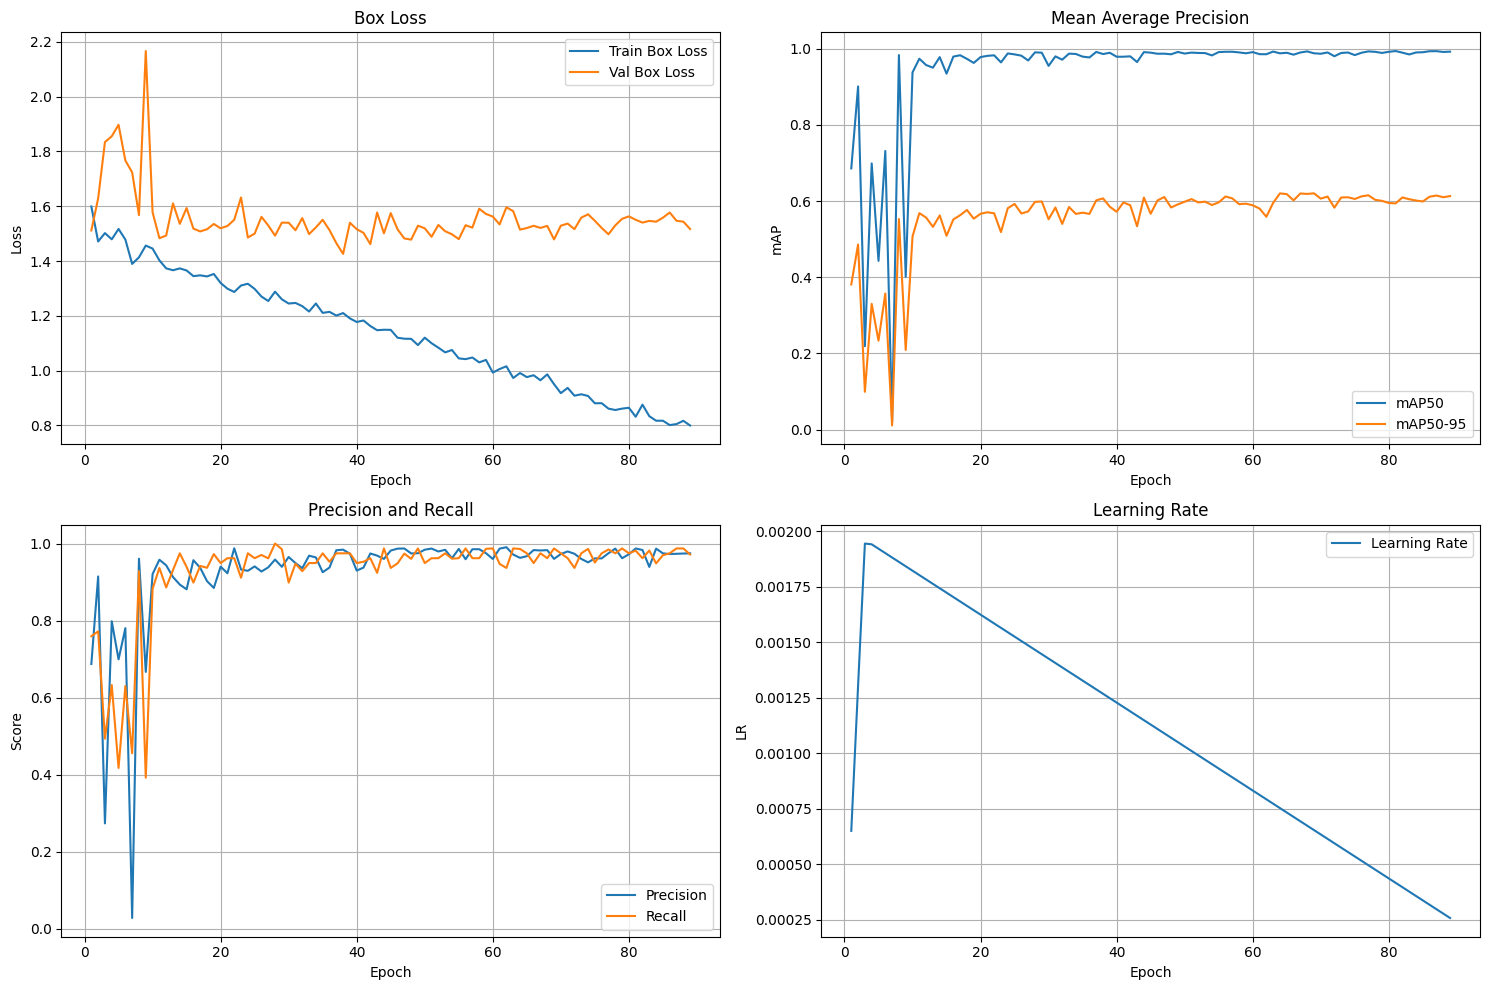

In [26]:
results_dir = Path('/content/bd_license_plate_training/yolov8_bd_plates22')
results_csv = "/content/bd_license_plate_training/yolov8_bd_plates2/results.csv"


df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()  # Remove extra spaces

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot training and validation loss
if 'train/box_loss' in df.columns:
    axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
    axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
    axes[0, 0].set_title('Box Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

# Plot mAP
if 'metrics/mAP50(B)' in df.columns:
    axes[0, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
    axes[0, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
    axes[0, 1].set_title('Mean Average Precision')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('mAP')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

# Plot Precision and Recall
if 'metrics/precision(B)' in df.columns:
    axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
    axes[1, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
    axes[1, 0].set_title('Precision and Recall')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

# Plot Learning Rate
if 'lr/pg0' in df.columns:
    axes[1, 1].plot(df['epoch'], df['lr/pg0'], label='Learning Rate')
    axes[1, 1].set_title('Learning Rate')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('LR')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

plt.tight_layout()

plt.show()

In [ ]:
best_model_path = Path('bd_license_plate_training/yolov8_bd_plates2/weights/best.pt')
if best_model_path.exists():
    import shutil
    shutil.copy2(best_model_path, "./bd_license_plate_detectorV2.pt")